In [4]:
!pip install torch torchvision -q

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

import torchvision
import torchvision.transforms.v2 as transforms
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt

In [5]:
train_set = torchvision.datasets.MNIST("./mnist/", train=True, download=True)
valid_set = torchvision.datasets.MNIST("./mnist/", train=False, download=True)

print(train_set)
print(valid_set)

100%|██████████| 9.91M/9.91M [00:00<00:00, 54.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.60MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 16.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.6MB/s]


Dataset MNIST
    Number of datapoints: 60000
    Root location: ./mnist/
    Split: Train
Dataset MNIST
    Number of datapoints: 10000
    Root location: ./mnist/
    Split: Test


In [6]:
x_0, y_0 = train_set[0]

print("Зображення:", x_0)
print("Тип зображення:", type(x_0))
print("Мітка (правильна цифра):", y_0)
print("Тип мітки:", type(y_0))

Зображення: <PIL.Image.Image image mode=L size=28x28 at 0x7C331681CC20>
Тип зображення: <class 'PIL.Image.Image'>
Мітка (правильна цифра): 5
Тип мітки: <class 'int'>


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Тип даних: torch.float32
Мін значення: tensor(0.)
Макс значення: tensor(1.)
Розмір: torch.Size([1, 28, 28])
Пристрій: cpu


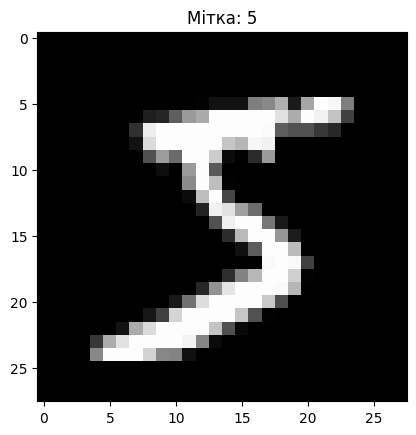

In [7]:
trans_preview = transforms.Compose([transforms.ToTensor()])
x_0_tensor = trans_preview(x_0)

print("Тип даних:", x_0_tensor.dtype)
print("Мін значення:", x_0_tensor.min())
print("Макс значення:", x_0_tensor.max())
print("Розмір:", x_0_tensor.size())
print("Пристрій:", x_0_tensor.device)

# Показуємо зображення
image = F.to_pil_image(x_0_tensor)
plt.imshow(image, cmap='gray')
plt.title(f"Мітка: {y_0}")
plt.show()

In [8]:
trans = transforms.Compose([transforms.ToTensor()])
train_set.transform = trans
valid_set.transform = trans

batch_size = 32
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size)

print("Train батчів:", len(train_loader))
print("Valid батчів:", len(valid_loader))

Train батчів: 1875
Valid батчів: 313


In [9]:
input_size = 1 * 28 * 28  # 784
n_classes = 10

layers = [
    nn.Flatten(),
    nn.Linear(input_size, 512),  # Вхідний шар
    nn.ReLU(),
    nn.Linear(512, 512),         # Прихований шар
    nn.ReLU(),
    nn.Linear(512, n_classes)    # Вихідний шар
]

model = nn.Sequential(*layers)
print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=512, bias=True)
  (2): ReLU()
  (3): Linear(in_features=512, out_features=512, bias=True)
  (4): ReLU()
  (5): Linear(in_features=512, out_features=10, bias=True)
)


In [10]:
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters())

In [11]:
train_N = len(train_loader.dataset)
valid_N = len(valid_loader.dataset)

def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

def train():
    loss = 0
    accuracy = 0
    model.train()
    for x, y in train_loader:
        output = model(x)
        optimizer.zero_grad()
        batch_loss = loss_function(output, y)
        batch_loss.backward()
        optimizer.step()
        loss += batch_loss.item()
        accuracy += get_batch_accuracy(output, y, train_N)
    print('Train - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

def validate():
    loss = 0
    accuracy = 0
    model.eval()
    with torch.no_grad():
        for x, y in valid_loader:
            output = model(x)
            loss += loss_function(output, y).item()
            accuracy += get_batch_accuracy(output, y, valid_N)
    print('Valid - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

In [12]:
epochs = 5

for epoch in range(epochs):
    print('Epoch: {}'.format(epoch))
    train()
    validate()

Epoch: 0
Train - Loss: 374.4965 Accuracy: 0.9394
Valid - Loss: 33.6045 Accuracy: 0.9671
Epoch: 1
Train - Loss: 160.8249 Accuracy: 0.9734
Valid - Loss: 29.2225 Accuracy: 0.9722
Epoch: 2
Train - Loss: 111.5674 Accuracy: 0.9813
Valid - Loss: 25.9506 Accuracy: 0.9743
Epoch: 3
Train - Loss: 81.2039 Accuracy: 0.9860
Valid - Loss: 25.8705 Accuracy: 0.9769
Epoch: 4
Train - Loss: 67.4023 Accuracy: 0.9885
Valid - Loss: 25.6438 Accuracy: 0.9796


Вектор передбачень: tensor([[-24.7575,  -9.5529, -16.6052,  11.6629, -27.9302,  18.1903, -23.8761,
         -11.1084, -14.5238,  -6.7852]], grad_fn=<AddmmBackward0>)
Передбачена цифра: 5
Правильна цифра: 5


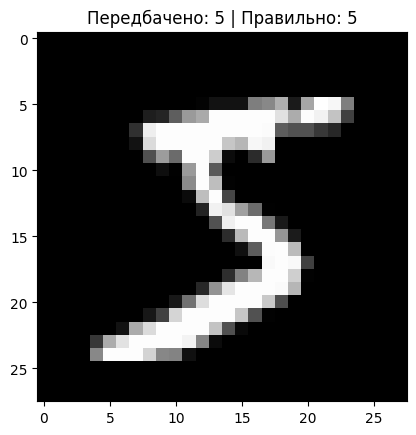

In [13]:
prediction = model(x_0_tensor)
print("Вектор передбачень:", prediction)
print("Передбачена цифра:", prediction.argmax().item())
print("Правильна цифра:", y_0)

# Візуалізація
image = F.to_pil_image(x_0_tensor)
plt.imshow(image, cmap='gray')
plt.title(f"Передбачено: {prediction.argmax().item()} | Правильно: {y_0}")
plt.show()